In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

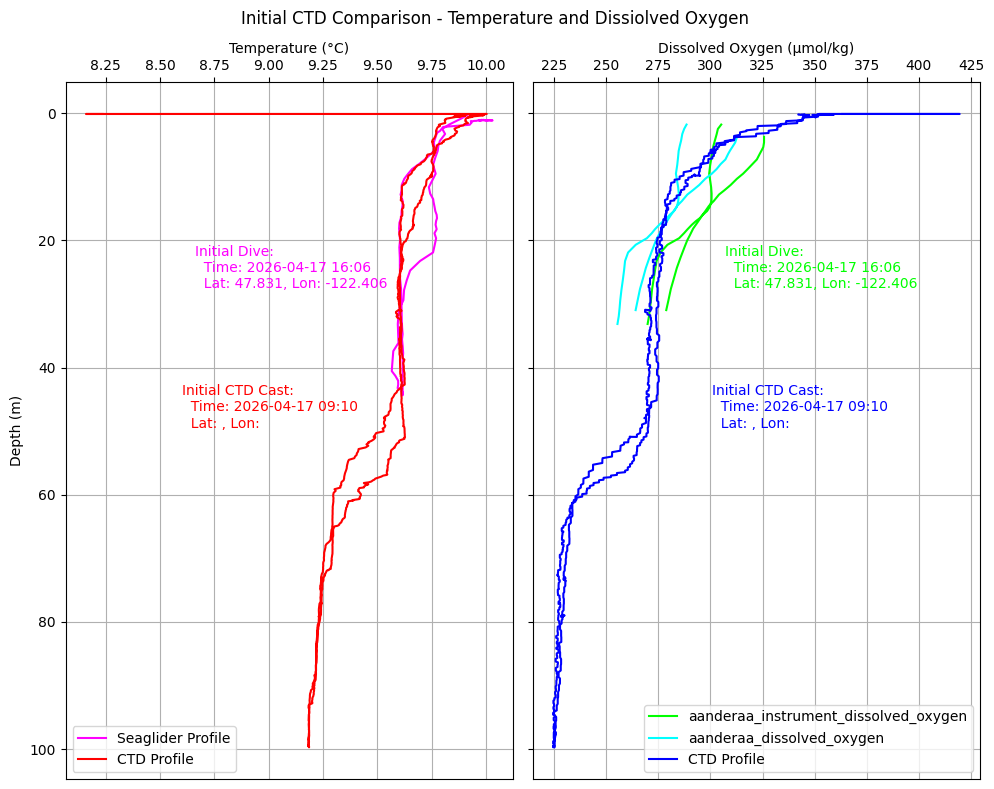

In [61]:
# Read in data from initial dives (usually use a file within dives 1-3 optimizing depth and time comparison)
initial_dive = xr.open_dataset('/Users/seaflow/Seagliders/p1940003.nc', decode_timedelta = True)

# Extract temperature and dissolved oxygen data from dive file
temp_initial = initial_dive['temperature'] 
instrument_DO_initial = initial_dive['aanderaa4330_instrument_dissolved_oxygen']
DO_initial = initial_dive['aanderaa4330_dissolved_oxygen']
depth_initial = initial_dive['depth'] 

# Convert to 1D arrays 
initial_temp_vals = temp_initial.values
initial_instrument_DO_vals = instrument_DO_initial.values
initial_DO_vals = DO_initial.values
initial_depth_vals = depth_initial.values

#Read in RBR CTD Data
ctd_initial = pd.read_excel('/Users/seaflow/Seagliders/RBR_04172026_Edmonds.xlsx', sheet_name='Data', header = 1)

#This is needed if CTD cast file contains more than one profile

'''
# Slice first profile (rows 0 to 1777)
ctd_initial = ctd_initial.iloc[:1777]
display(ctd_initial)
'''

# Extract temperature and oxygen from CTD
depth_ctd1 = ctd_initial['Depth']   
temp_ctd1 = ctd_initial['Temperature']
oxy_ctd1 = ctd_initial['Dissolved O2 concentration']    

# Plot Initial Temperature and Oxygen Comparisons
fig, ax = plt.subplots(1,2, figsize=(10,8), sharey=True)
fig.suptitle('Initial CTD Comparison - Temperature and Dissiolved Oxygen')
fig.tight_layout()

# Temperature Comparison
ax[0].plot(initial_temp_vals, initial_depth_vals, label='Seaglider Profile', color='magenta')
ax[0].plot(temp_ctd1, depth_ctd1, label='CTD Profile', color='red')
ax[0].legend(loc='lower left')
ax[0].set_xlabel('Temperature (\u00B0C)')
ax[0].set_ylabel('Depth (m)')
ax[0].xaxis.set_ticks_position('top')
ax[0].xaxis.set_label_position('top')
ax[0].grid(True)

# Dissolved Oxygen Comparison
ax[1].plot(initial_instrument_DO_vals, initial_depth_vals, label='aanderaa_instrument_dissolved_oxygen', color='lime')
ax[1].plot(initial_DO_vals, initial_depth_vals, label='aanderaa_dissolved_oxygen', color='cyan')
ax[1].plot(oxy_ctd1, depth_ctd1, label='CTD Profile', color='blue')
ax[1].legend(loc='lower right')
ax[1].set_xlabel('Dissolved Oxygen (\u03BCmol/kg)')
ax[1].xaxis.set_ticks_position('top')
ax[1].xaxis.set_label_position('top')
ax[1].grid(True)

# Depth Profile
ax[0].invert_yaxis()

# Annotate times onto plots
time1_sg = pd.Timestamp(initial_dive['time'].values[0]).strftime('%Y-%m-%d %H:%M')
time1_ctd = pd.Timestamp(ctd_initial['Time'].values[0]).strftime('%Y-%m-%d %H:%M')

# Input CTD lat and lon manually, not on all datasheets
ax[0].text(0.29, 0.7,
         f"Initial Dive:\n  Time: {time1_sg}\n  Lat: {initial_dive['latitude'].values[0]:.3f}, Lon: {initial_dive['longitude'].values[0]:.3f}",
         transform=ax[0].transAxes, color='magenta', fontsize=10, va='bottom')

ax[0].text(0.26, 0.5,
         f"Initial CTD Cast:\n  Time: {time1_ctd}\n  Lat: , Lon: ",
         transform=ax[0].transAxes, color='red', fontsize=10, va='bottom')

ax[1].text(0.43, 0.7,
         f"Initial Dive:\n  Time: {time1_sg}\n  Lat: {initial_dive['latitude'].values[0]:.3f}, Lon: {initial_dive['longitude'].values[0]:.3f}",
         transform=ax[1].transAxes, color='lime', fontsize=10, va='bottom')

ax[1].text(0.4, 0.5,
         f"Initial CTD Cast:\n  Time: {time1_ctd}\n  Lat: , Lon: ",
         transform=ax[1].transAxes, color='blue', fontsize=10, va='bottom')


#plt.savefig(Save as ['mission name'_Initial_CTD_Comparison.png])
plt.show()

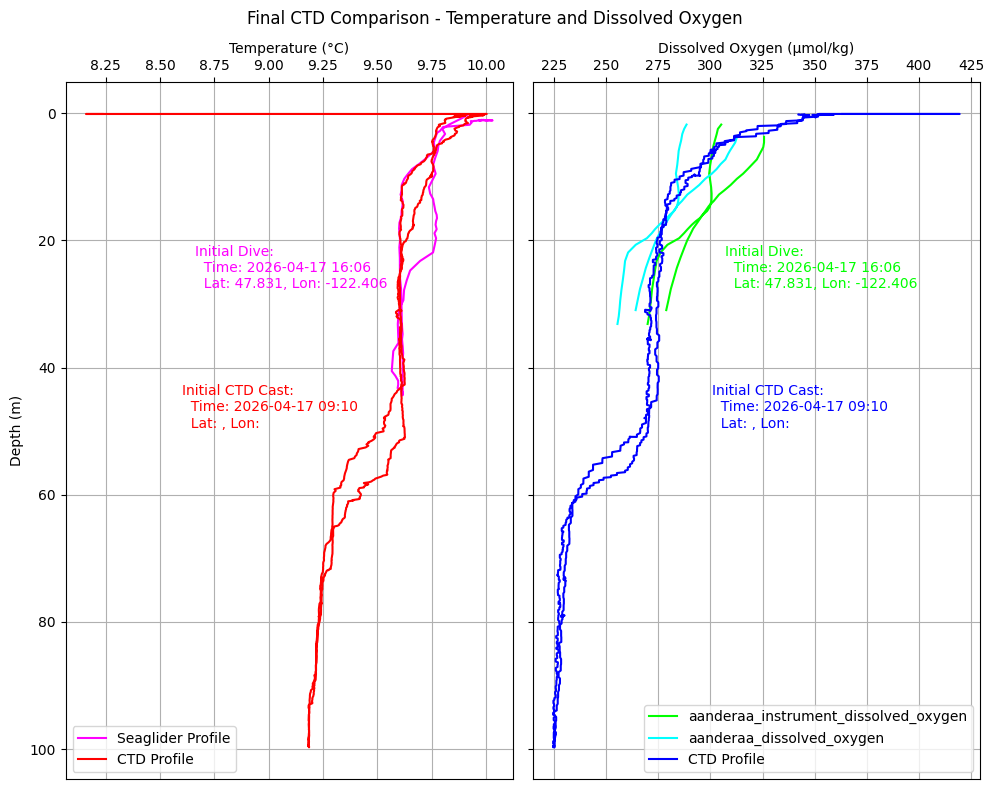

In [62]:
# Read in data from final dives (usually within the last 3 dives optimizing depth and time comparison)
final_dive = xr.open_dataset('INSERT SEAGLIDER FILE NAME', decode_timedelta = True)

# Extract temperature and dissolved oxygen data from dive file
temp_final = final_dive['temperature'] 
instrument_DO_final = final_dive['aanderaa4330_instrument_dissolved_oxygen']
DO_final = final_dive['aanderaa4330_dissolved_oxygen']
depth_final = final_dive['depth'] 

# Convert to 1D arrays 
final_temp_vals = temp_final.values
final_instrument_DO_vals = instrument_DO_final.values
final_DO_vals = DO_final.values
final_depth_vals = depth_final.values

#Read in RBR CTD Data
ctd_final = pd.read_excel('INSERT CTD FILE NAME', sheet_name='Data', header = 1)

#This is needed if CTD cast file contains more than one profile
'''
# Slice first profile (rows 0 to 1777)
ctd_final = ctd_final.iloc[:1777]
display(ctd_final)
'''

#Extract temp and oxygen from CTD
depth_ctdF = ctd_final['Depth']   
temp_ctdF = ctd_final['Temperature']
oxy_ctdF = ctd_final['Dissolved O2 concentration']    

# Plot Initial Temperature and Oxygen Comparisons
fig, ax = plt.subplots(1,2, figsize=(10,8), sharey=True)
fig.suptitle('Final CTD Comparison - Temperature and Dissolved Oxygen')
fig.tight_layout()

# Temperature Comparison
ax[0].plot(final_temp_vals, final_depth_vals, label='Seaglider Profile', color='magenta')
ax[0].plot(temp_ctdF, depth_ctdF, label='CTD Profile', color='red')
ax[0].legend(loc='lower left')
ax[0].set_xlabel('Temperature (\u00B0C)')
ax[0].set_ylabel('Depth (m)')
ax[0].xaxis.set_ticks_position('top')
ax[0].xaxis.set_label_position('top')
ax[0].grid(True)

# Dissolved Oxygen Comparison
ax[1].plot(final_instrument_DO_vals, final_depth_vals, label='aanderaa_instrument_dissolved_oxygen', color='lime')
ax[1].plot(final_DO_vals, final_depth_vals, label='aanderaa_dissolved_oxygen', color='cyan')
ax[1].plot(oxy_ctdF, depth_ctdF, label='CTD Profile', color='blue')
ax[1].legend(loc='lower right')
ax[1].set_xlabel('Dissolved Oxygen (\u03BCmol/kg)')
ax[1].xaxis.set_ticks_position('top')
ax[1].xaxis.set_label_position('top')
ax[1].grid(True)

# Depth Profile
ax[0].invert_yaxis()

# Annotate times onto plots
timeF_sg = pd.Timestamp(final_dive['time'].values[0]).strftime('%Y-%m-%d %H:%M')
timeF_ctd = pd.Timestamp(ctd_final['Time'].values[0]).strftime('%Y-%m-%d %H:%M')

# Input CTD lat and lon manually, not on all datasheets
ax[0].text(0.29, 0.7,
         f"Initial Dive:\n  Time: {timeF_sg}\n  Lat: {final_dive['latitude'].values[0]:.3f}, Lon: {final_dive['longitude'].values[0]:.3f}",
         transform=ax[0].transAxes, color='magenta', fontsize=10, va='bottom')

ax[0].text(0.26, 0.5,
         f"Initial CTD Cast:\n  Time: {timeF_ctd}\n  Lat: , Lon: ",
         transform=ax[0].transAxes, color='red', fontsize=10, va='bottom')

ax[1].text(0.43, 0.7,
         f"Initial Dive:\n  Time: {timeF_sg}\n  Lat: {final_dive['latitude'].values[0]:.3f}, Lon: {final_dive['longitude'].values[0]:.3f}",
         transform=ax[1].transAxes, color='lime', fontsize=10, va='bottom')

ax[1].text(0.4, 0.5,
         f"Initial CTD Cast:\n  Time: {timeF_ctd}\n  Lat: , Lon: ",
         transform=ax[1].transAxes, color='blue', fontsize=10, va='bottom')


#plt.savefig(Save as ['mission name'_Final_CTD_Comparison.png])
plt.show()